In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
df = pd.read_csv("provider_month_NM_organization.csv")
df

,billing_provider_npi,month,paid_t,claims_t,hcpcs_count_t,beneficiaries_proxy_t,paid_per_claim_t,claims_per_beneficiaries_proxy_t,paid_per_beneficiaries_proxy_t,top_code_paid_share,...,max_claims_single_code,min_claims_single_code,std_claims_per_code,iqr_claims_per_code,mad_claims_per_code,skew_claims_per_code,kurt_claims_per_code,claims_code_range,claims_code_energy,num_codes_above_mean_claims
0,1003031436,2020-07-01,3230.32,39,1,14,82.828718,2.785714,230.737143,1.000000,...,39,39,NaN,0.0,0.0,NaN,NaN,0,1521,0
1,1003031436,2020-08-01,4173.80,51,1,19,81.839216,2.684211,219.673684,1.000000,...,51,51,NaN,0.0,0.0,NaN,NaN,0,2601,0
2,1003031436,2020-09-01,6920.26,77,2,34,89.873506,2.264706,203.537059,0.756080,...,63,14,34.648232,24.5,24.5,NaN,NaN,49,4165,1
3,1003031436,2020-10-01,7424.18,90,1,32,82.490889,2.812500,232.005625,1.000000,...,90,90,NaN,0.0,0.0,NaN,NaN,0,8100,0
4,1003031436,2020-11-01,9079.72,110,2,46,82.542909,2.391304,197.385217,0.761026,...,85,25,42.426407,30.0,30.0,NaN,NaN,60,7850,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147562,1992966923,2021-09-01,1926.20,20,1,18,96.310000,1.111111,107.011111,1.000000,...,20,20,NaN,0.0,0.0,NaN,NaN,0,400,0
147563,1992966923,2021-10-01,2118.82,22,1,18,96.310000,1.222222,117.712222,1.000000,...,22,22,NaN,0.0,0.0,NaN,NaN,0,484,0
147564,1992966923,2021-11-01,1733.58,18,1,17,96.310000,1.058824,101.975294,1.000000,...,18,18,NaN,0.0,0.0,NaN,NaN,0,324,0
147565,1992966923,2022-01-01,1637.27,17,1,14,96.310000,1.214286,116.947857,1.000000,...,17,17,NaN,0.0,0.0,NaN,NaN,0,289,0


In [9]:
month_ser = pd.to_datetime(df["month"])
df = df[month_ser <= "2024-12-31"]
months_per_npi = df.groupby("billing_provider_npi")["month"].nunique()
keep_npis = months_per_npi[months_per_npi >= 12].index
df = df[df["billing_provider_npi"].isin(keep_npis)]


In [10]:
df

,billing_provider_npi,month,paid_t,claims_t,hcpcs_count_t,beneficiaries_proxy_t,paid_per_claim_t,claims_per_beneficiaries_proxy_t,paid_per_beneficiaries_proxy_t,top_code_paid_share,...,max_claims_single_code,min_claims_single_code,std_claims_per_code,iqr_claims_per_code,mad_claims_per_code,skew_claims_per_code,kurt_claims_per_code,claims_code_range,claims_code_energy,num_codes_above_mean_claims
0,1003031436,2020-07-01,3230.32,39,1,14,82.828718,2.785714,230.737143,1.000000,...,39,39,NaN,0.0,0.0,NaN,NaN,0,1521,0
1,1003031436,2020-08-01,4173.80,51,1,19,81.839216,2.684211,219.673684,1.000000,...,51,51,NaN,0.0,0.0,NaN,NaN,0,2601,0
2,1003031436,2020-09-01,6920.26,77,2,34,89.873506,2.264706,203.537059,0.756080,...,63,14,34.648232,24.5,24.5,NaN,NaN,49,4165,1
3,1003031436,2020-10-01,7424.18,90,1,32,82.490889,2.812500,232.005625,1.000000,...,90,90,NaN,0.0,0.0,NaN,NaN,0,8100,0
4,1003031436,2020-11-01,9079.72,110,2,46,82.542909,2.391304,197.385217,0.761026,...,85,25,42.426407,30.0,30.0,NaN,NaN,60,7850,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147562,1992966923,2021-09-01,1926.20,20,1,18,96.310000,1.111111,107.011111,1.000000,...,20,20,NaN,0.0,0.0,NaN,NaN,0,400,0
147563,1992966923,2021-10-01,2118.82,22,1,18,96.310000,1.222222,117.712222,1.000000,...,22,22,NaN,0.0,0.0,NaN,NaN,0,484,0
147564,1992966923,2021-11-01,1733.58,18,1,17,96.310000,1.058824,101.975294,1.000000,...,18,18,NaN,0.0,0.0,NaN,NaN,0,324,0
147565,1992966923,2022-01-01,1637.27,17,1,14,96.310000,1.214286,116.947857,1.000000,...,17,17,NaN,0.0,0.0,NaN,NaN,0,289,0


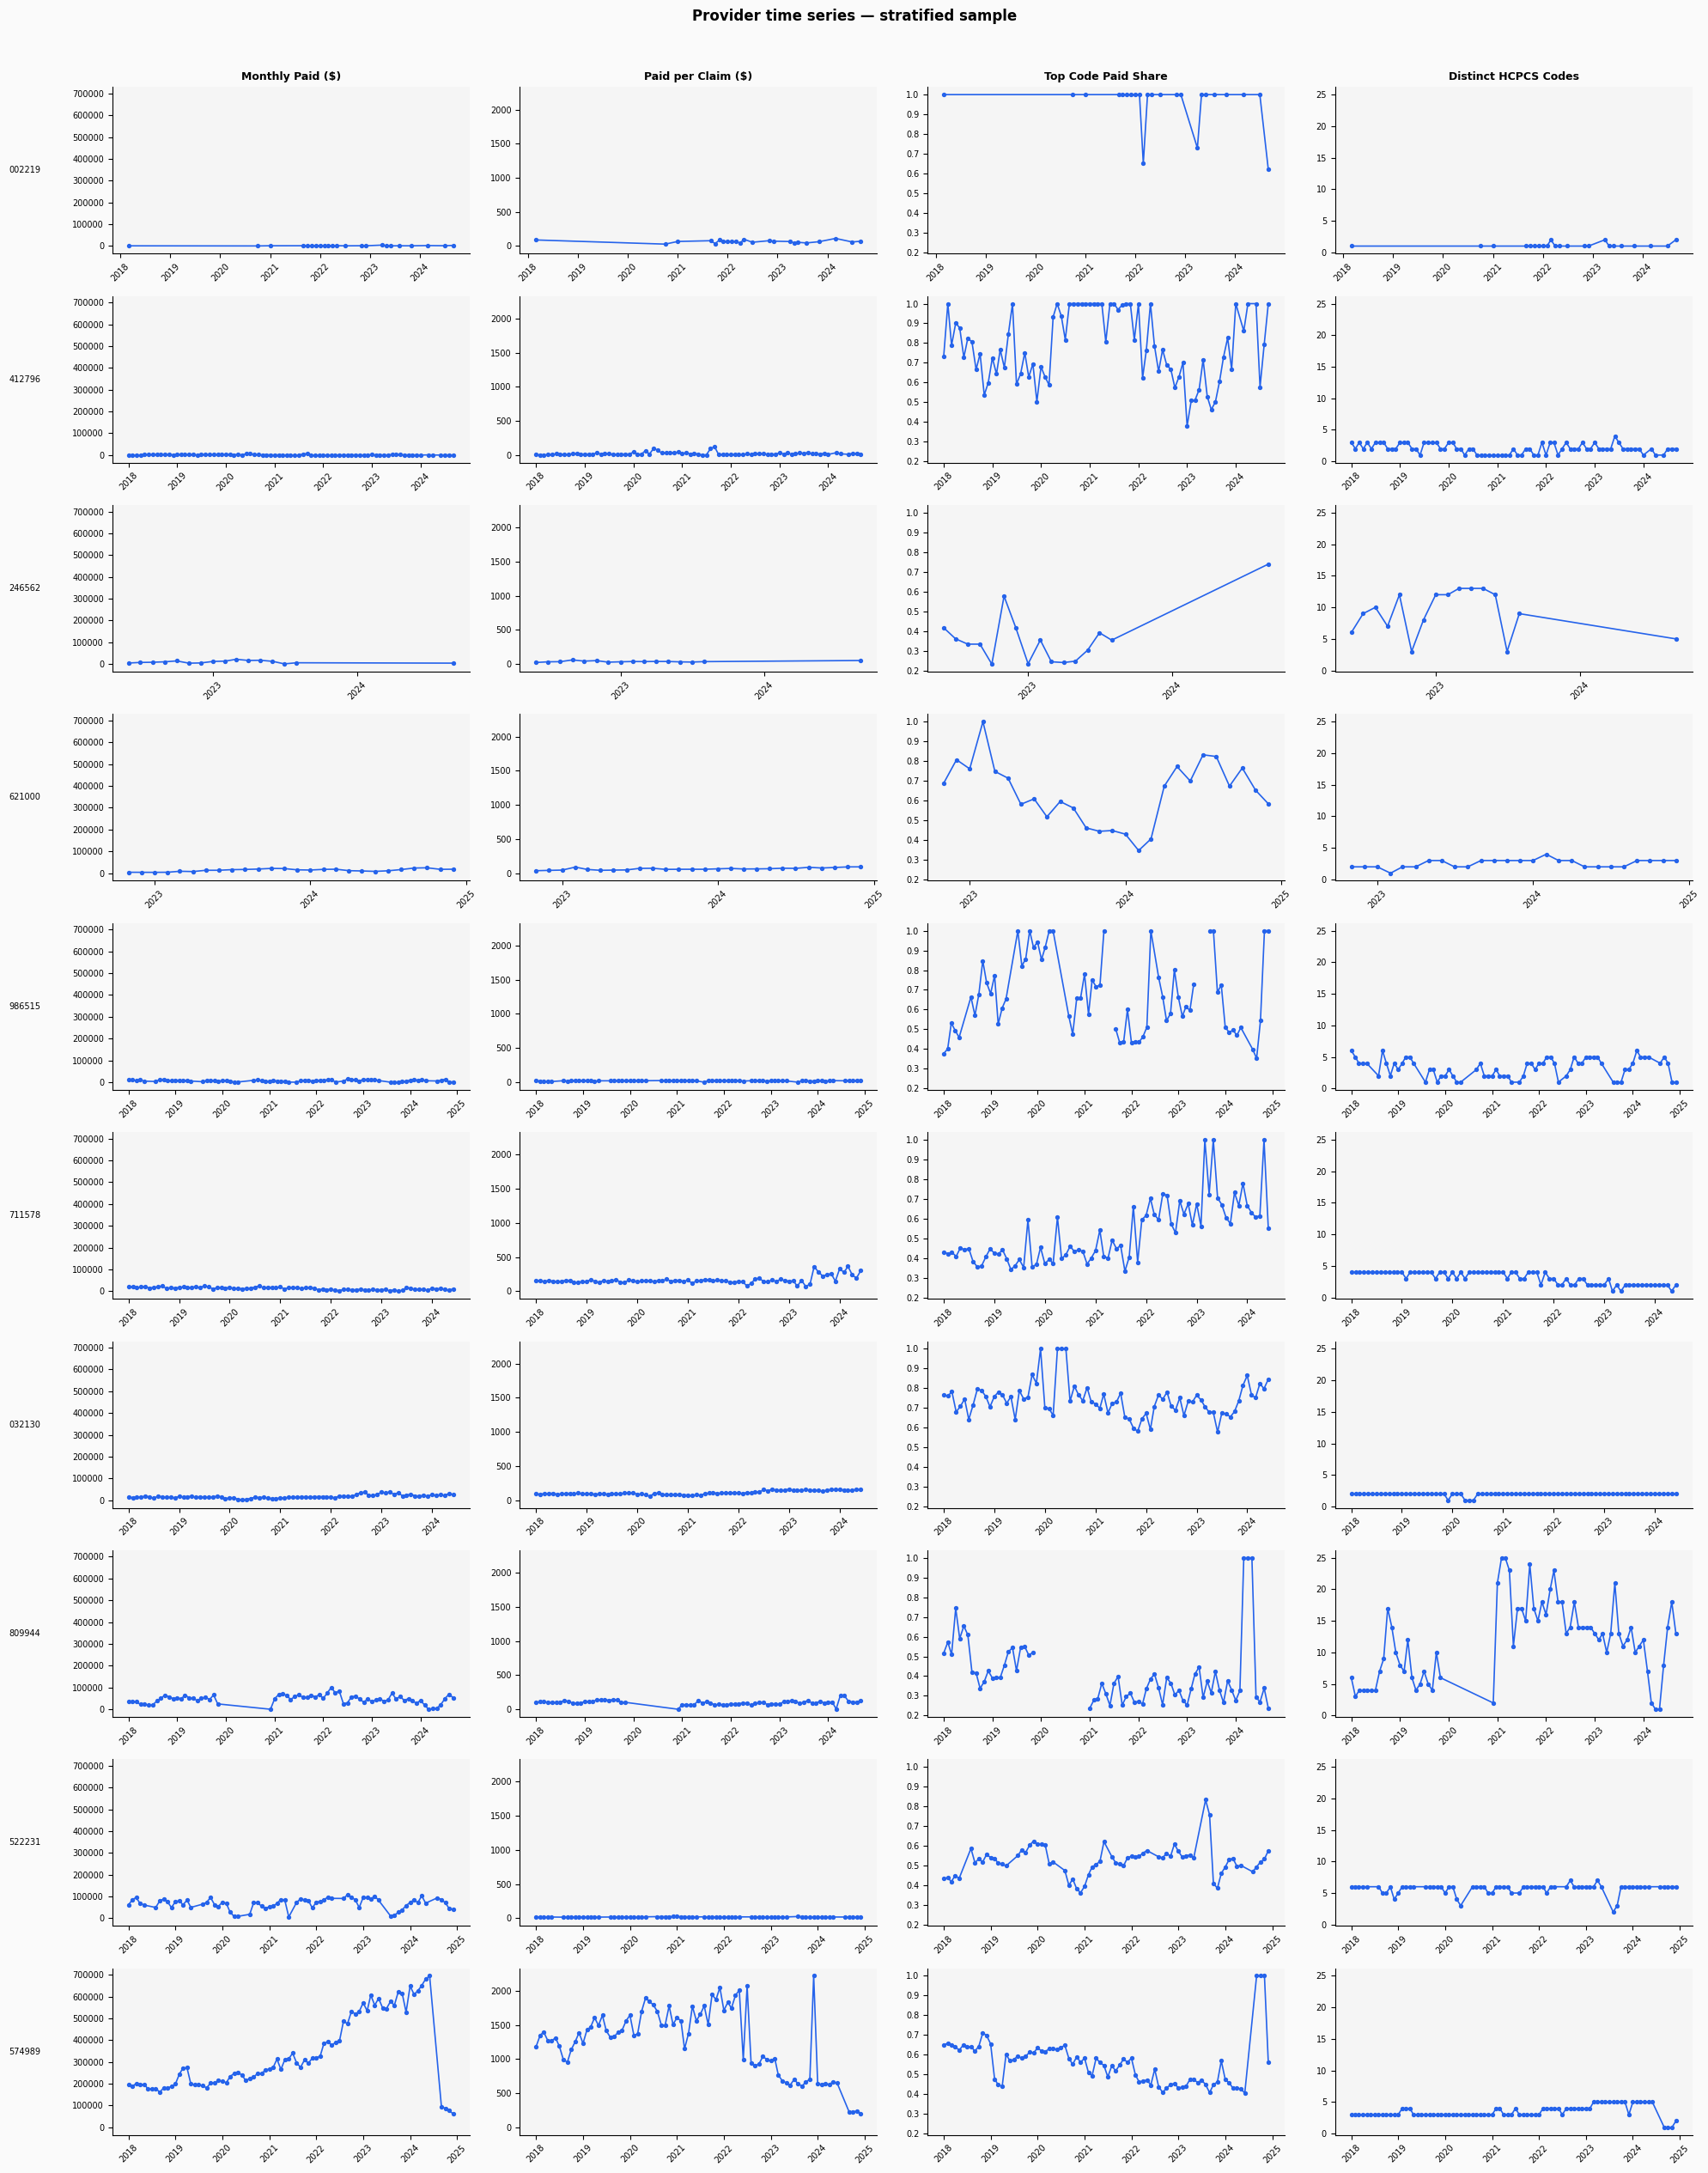

In [11]:


FEATURES = ["paid_t", "paid_per_claim_t", "top_code_paid_share", "hcpcs_count_t"]
TITLES   = ["Monthly Paid ($)", "Paid per Claim ($)", "Top Code Paid Share", "Distinct HCPCS Codes"]

# Stratified sample
summary = df.groupby("billing_provider_npi")["paid_t"].sum().sort_values()
deciles  = pd.qcut(summary, q=10, labels=False)
chosen   = (
    summary.groupby(deciles)
           .apply(lambda g: g.sample(1, random_state=42))
           .droplevel(0)
           .index
)
subset = df[df["billing_provider_npi"].isin(chosen)].copy()
subset["month"] = pd.to_datetime(subset["month"])

n_providers = len(chosen)
n_features  = len(FEATURES)

fig, axes = plt.subplots(
    n_providers, n_features,
    figsize=(5 * n_features, 2.5 * n_providers),
    sharey="col",   # same y-scale within each feature column
)
fig.patch.set_facecolor("#fafafa")

for row, npi in enumerate(chosen):
    prov = subset[subset["billing_provider_npi"] == npi].sort_values("month")
    for col, (feat, title) in enumerate(zip(FEATURES, TITLES)):
        ax = axes[row, col]
        ax.set_facecolor("#f5f5f5")
        ax.plot(prov["month"], prov[feat], color="#2563eb", lw=1.2)
        # Mark gaps (months with no data) visually — don't connect across them
        ax.scatter(prov["month"], prov[feat], s=8, color="#2563eb", zorder=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
        if row == 0:
            ax.set_title(title, fontsize=9, fontweight="bold")
        if col == 0:
            ax.set_ylabel(str(npi)[-6:], fontsize=7, rotation=0, labelpad=40, va="center")

fig.suptitle("Provider time series — stratified sample", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("provider_timeseries_eda.png", dpi=150, bbox_inches="tight")
plt.show()
